# Alpha Shapes

Alpha-shapes reveal topology as a scale parameter varies.


## Point cloud and alpha sweep


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

from scipy.spatial import Delaunay
import ipywidgets as widgets
P = np.r_[rng.normal([-0.7,0.2],[0.2,0.15],(90,2)), rng.normal([0.5,-0.2],[0.25,0.18],(90,2))]
tri = Delaunay(P)

def circumradius(a, b, c):
    A = np.linalg.norm(b-c); B = np.linalg.norm(a-c); C = np.linalg.norm(a-b)
    s = 0.5*(A+B+C)
    area2 = max(s*(s-A)*(s-B)*(s-C), 1e-14)
    return A*B*C/(4*np.sqrt(area2))
R = np.array([circumradius(*P[t]) for t in tri.simplices])


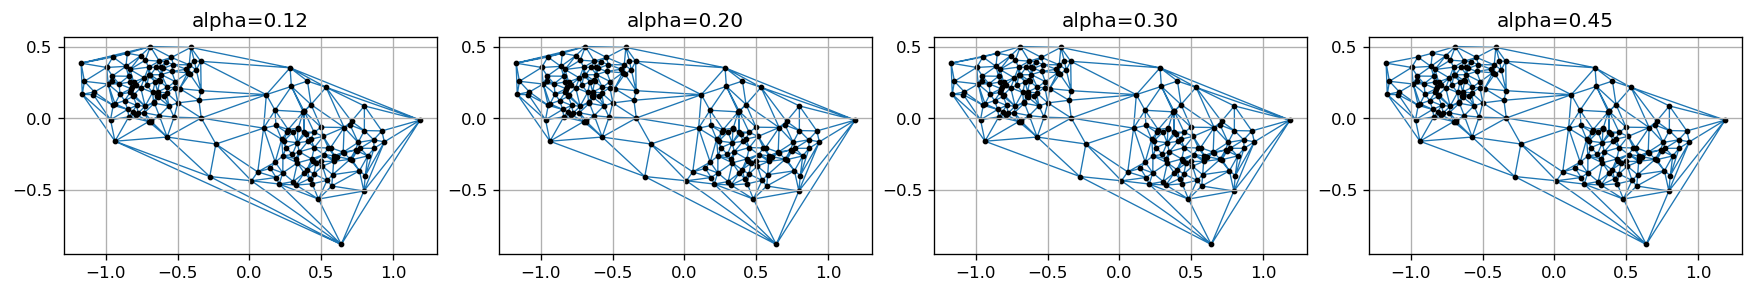

In [2]:
alphas = [0.12, 0.2, 0.3, 0.45]
fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.5), constrained_layout=True)
for ax, a in zip(axes, alphas):
    keep = R < (1/a)
    ax.triplot(P[:,0], P[:,1], tri.simplices[keep], color='tab:blue', lw=0.8)
    ax.scatter(P[:,0], P[:,1], s=6, c='k')
    ax.set_title(f'alpha={a:.2f}')
    ax.set_aspect('equal')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive slider
